<a href="https://colab.research.google.com/github/samarthya04/AD_Lab/blob/main/2205498_Week_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
iris = datasets.load_iris()

In [3]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
X = StandardScaler().fit_transform(iris.data)

In [5]:
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

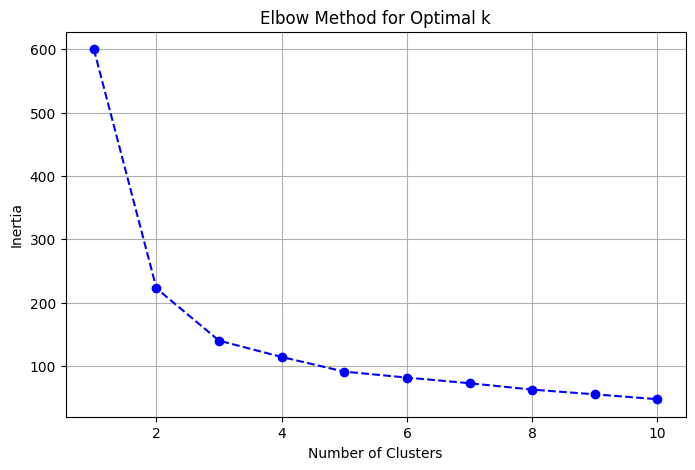

In [6]:
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid()
plt.show()

In [7]:
k_optimal = 3

In [8]:
def run_clustering(model, X):
    labels = model.fit_predict(X)
    if len(set(labels)) > 1:
        return labels, silhouette_score(X, labels)
    return labels, -1

In [9]:
# K-Means Clustering
kmeans_labels, kmeans_score = run_clustering(KMeans(n_clusters=k_optimal), X)

# Agglomerative Clustering
agg_labels, agg_score = run_clustering(AgglomerativeClustering(n_clusters=k_optimal), X)

# DBSCAN Clustering
dbscan_labels, dbscan_score = run_clustering(DBSCAN(eps=0.5, min_samples=5), X)

# Mean Shift Clustering
bandwidth = estimate_bandwidth(X, quantile=0.2)
mean_shift_labels, mean_shift_score = run_clustering(MeanShift(bandwidth=bandwidth), X)

In [10]:
silhouette_scores = {
    "K-Means": kmeans_score,
    "Agglomerative": agg_score,
    "DBSCAN": dbscan_score,
    "Mean Shift": mean_shift_score
}

In [11]:
print("\nSilhouette Scores:")
for method, score in silhouette_scores.items():
    print(f"{method}: {score:.4f}")


Silhouette Scores:
K-Means: 0.4566
Agglomerative: 0.4467
DBSCAN: 0.3565
Mean Shift: 0.3585


In [12]:
def plot_clusters(X, labels, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.7)
    plt.xlabel('Sepal length (cm)')
    plt.ylabel('Sepal width (cm)')
    plt.title(title)
    plt.colorbar(label='Cluster Label')
    plt.show()

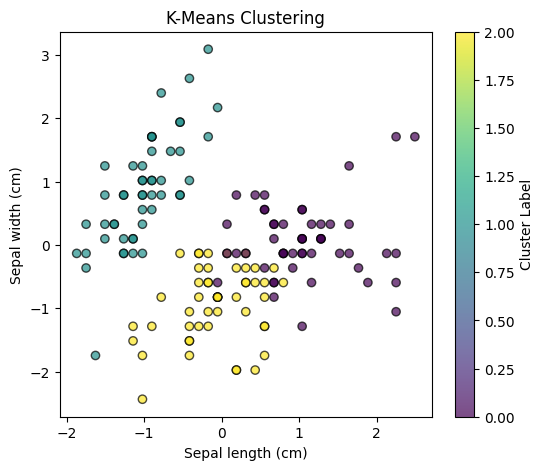

In [13]:
plot_clusters(X, kmeans_labels, "K-Means Clustering")

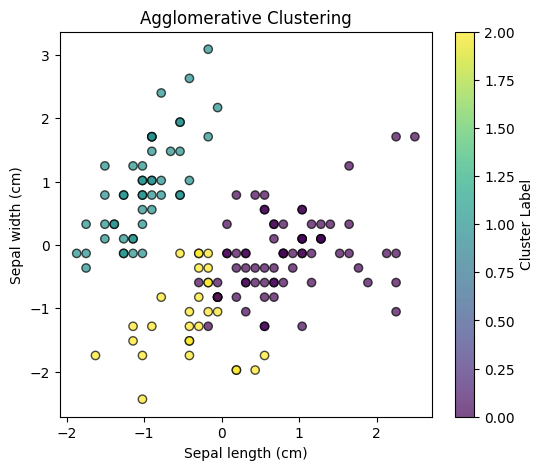

In [14]:
plot_clusters(X, agg_labels, "Agglomerative Clustering")

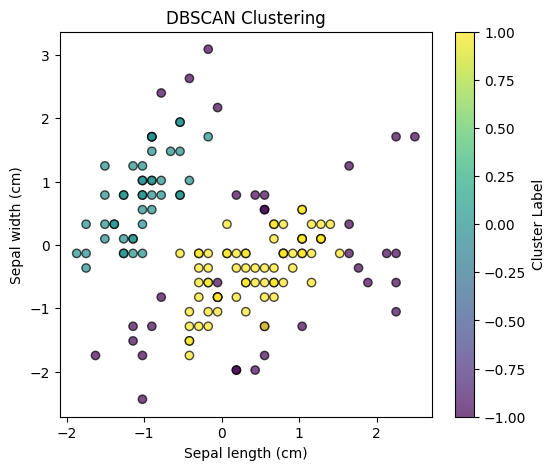

In [15]:
plot_clusters(X, dbscan_labels, "DBSCAN Clustering")

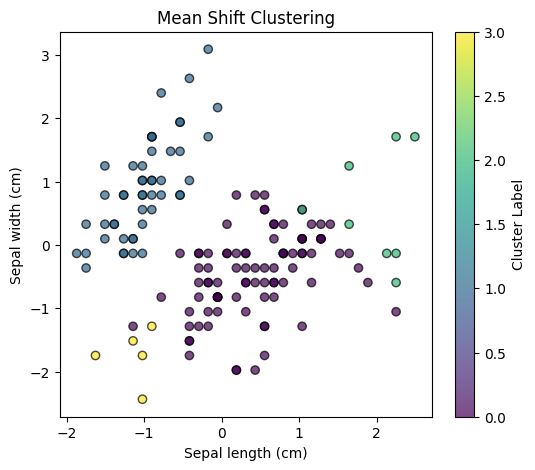

In [16]:
plot_clusters(X, mean_shift_labels, "Mean Shift Clustering")